In [1]:
import math
import cv2
import numpy as np
from scipy import sparse, signal
import imageio.v3 as iio
import matplotlib.pyplot as plt
import mediapipe as mp
from copy import deepcopy
from PIL import Image, ImageDraw
from mpl_toolkits.axes_grid1 import ImageGrid

число фреймов: 1547, размер: 480 x 640


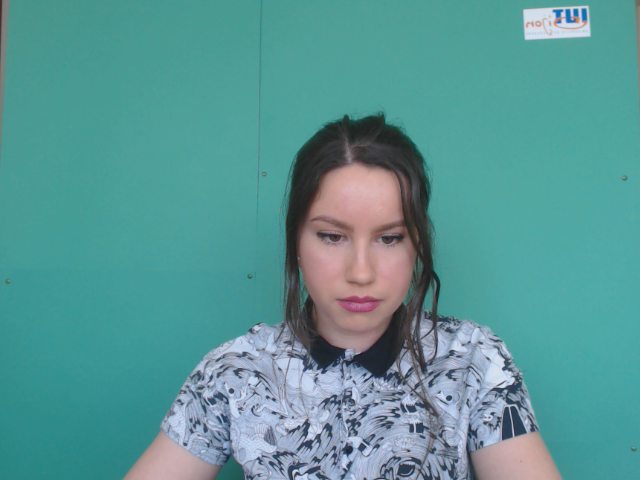

In [3]:
# прочитаем видео из файла
video_file = "data/UBFC-rPPG/subject1/vid.avi"

frames = iio.imread(video_file, plugin="pyav")
num_frames, img_height, img_width = frames.shape[:3]

print(f"число фреймов: {num_frames}, размер: {img_height} x {img_width}")
Image.fromarray(frames[100])

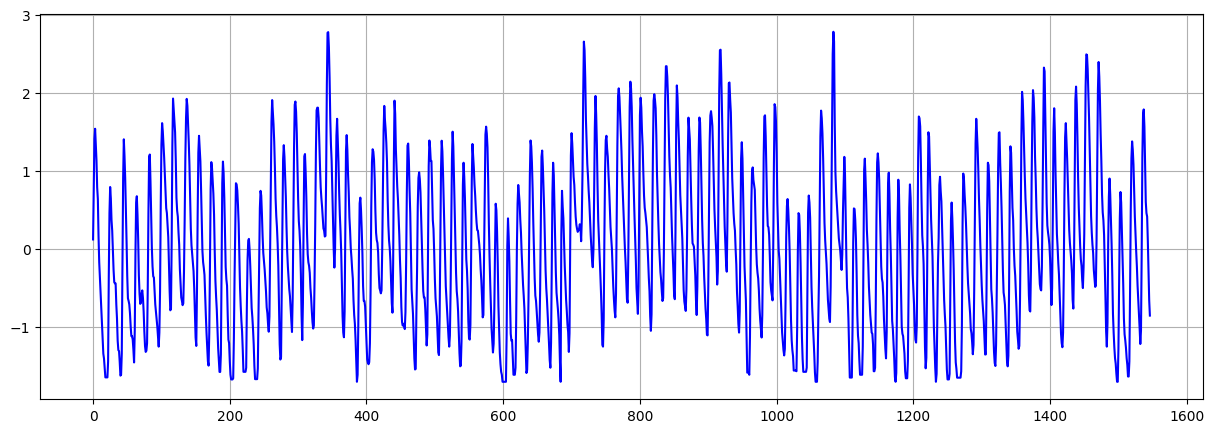

In [5]:
# прочитаем BVP (Blood Volume Pulse) данные
def read_wave(bvp_file):
    with open(bvp_file, "r") as f:
        s = f.read()
        s = s.split("\n")
        bvp = [float(x) for x in s[0].split()]
    return np.asarray(bvp)

bvp_file = "data/UBFC-rPPG/subject1/ground_truth.txt"
gt_bvp = read_wave(bvp_file)

plt.figure(figsize = (15, 5))
plt.grid(True)
plt.plot(gt_bvp, c="blue")

In [6]:
# детектируем лицо на видео с помощью MediaPipe
mp_face_detection = mp.solutions.face_detection

face_bboxes = np.zeros((num_frames, 4), dtype=int)

with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5) as face_detection:
  for n, frame in enumerate(frames):
    results = face_detection.process(frame)
    
    if not results.detections:
      print(f"frame: {n} face not detected")
      continue
    
    for detection in results.detections:
      box = detection.location_data.relative_bounding_box
      x, y, w, h = map(int, [box.xmin * img_width, box.ymin * img_height, box.width * img_width, box.height * img_height])
      face_bboxes[n] = x, y, x + w, y + h

I0000 00:00:1738416413.916769   67471 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1738416413.933726   68462 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.144.03), renderer: NVIDIA GeForce RTX 3090 Ti/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1738416413.946284   68458 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


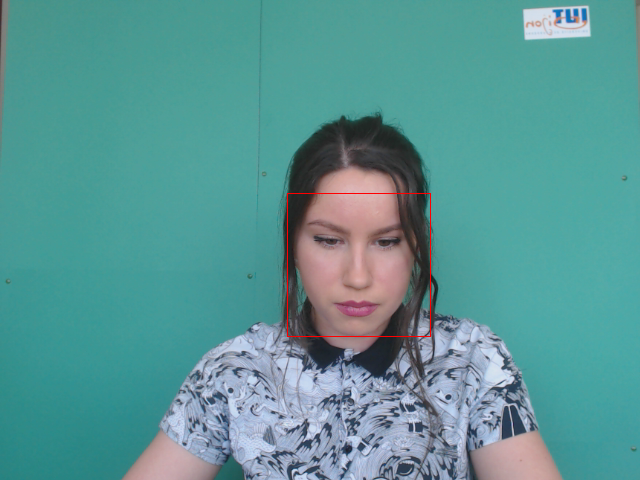

In [8]:
# лицо на n-м кадре
n = 1000
image = Image.fromarray(frames[n])
draw = ImageDraw.Draw(image).rectangle(face_bboxes[n].tolist(), outline ="red") 
image

In [9]:
# вырезаем и ресайзим все лица в 72 x 72 
w = h = 72
faces = np.zeros((num_frames, h, w, 3), dtype=np.uint8)

for n, (frame, (x1, y1, x2, y2)) in enumerate(zip(frames, face_bboxes)):
    crop = frame[y1: y2, x1: x2]
    faces[n] = cv2.resize(crop, (w, h), interpolation=cv2.INTER_AREA) 

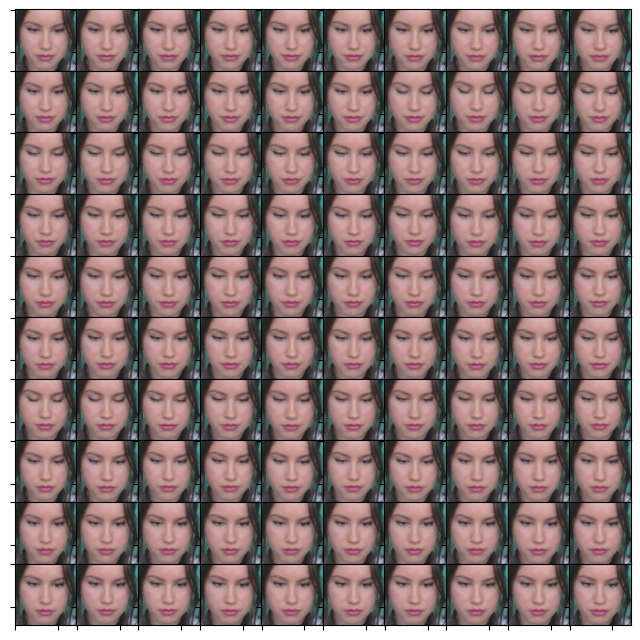

In [10]:
# выведем первые 100 лиц
fig = plt.figure(figsize=(8, 8))
grid = ImageGrid(fig, 111, nrows_ncols=(10, 10), axes_pad=0.0)

for ax, im in zip(grid, faces[:100]):
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.imshow(im)

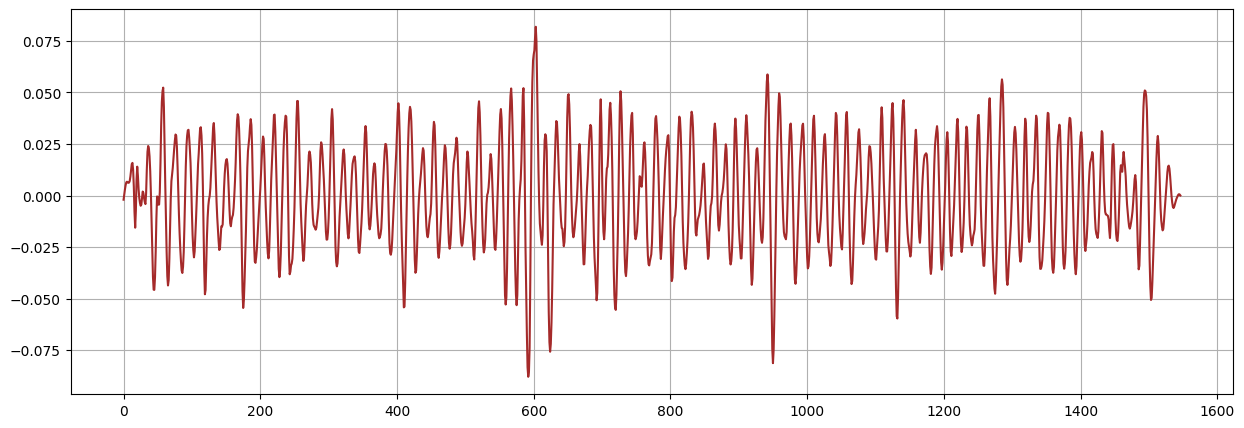

In [11]:
def _process_video(frames):
    """Calculates the average value of each frame."""
    RGB = []
    for frame in frames:
        summation = np.sum(np.sum(frame, axis=0), axis=0)
        RGB.append(summation / (frame.shape[0] * frame.shape[1]))
    return np.asarray(RGB)

def detrend(input_signal, lambda_value):
    signal_length = input_signal.shape[0]
    
    # observation matrix
    H = np.identity(signal_length)
    ones = np.ones(signal_length)
    minus_twos = -2 * np.ones(signal_length)
    
    diags_data = np.array([ones, minus_twos, ones])
    diags_index = np.array([0, 1, 2])
    
    D = sparse.spdiags(diags_data, diags_index, (signal_length - 2), signal_length).toarray()
    filtered_signal = np.dot((H - np.linalg.inv(H + (lambda_value ** 2) * np.dot(D.T, D))), input_signal)
    
    return filtered_signal

# Алгоритм Plane-Orthogonal-to-Skin (POS) (https://pure.tue.nl/ws/files/31563684/TBME_00467_2016_R1_preprint.pdf)
# Реализация взята из https://github.com/ubicomplab/rPPG-Toolbox/blob/cc143fd53fad935b1f349047ad5d0960ea88be86/unsupervised_methods/methods/POS_WANG.py#L23

# TODO: рефакторинг!
def POS_WANG(faces, fps=30):
    win_sec = 1.6 # длина окна в секундах
    RGB = _process_video(faces)
    N = RGB.shape[0]
    H = np.zeros((1, N))
    k = math.ceil(win_sec * fps) # число кадров в окне

    for n in range(N):
        m = n - k
        
        if m >= 0:
            Cn = np.true_divide(RGB[m:n, :], np.mean(RGB[m:n, :], axis=0))
            Cn = np.asmatrix(Cn).H
            S = np.matmul(np.array([[0, 1, -1], [-2, 1, 1]]), Cn)
            h = S[0, :] + (np.std(S[0, :]) / np.std(S[1, :])) * S[1, :]
            mean_h = np.mean(h)
            
            for temp in range(h.shape[1]):
                h[0, temp] = h[0, temp] - mean_h
        
            H[0, m:n] = H[0, m:n] + (h[0])

    BVP = H
    BVP = detrend(np.asmatrix(BVP).H, 100) # вычитание тренда из данных BVP
    BVP = np.asarray(np.transpose(BVP))[0]

    # коэффициенты фильтра Баттерворта https://en.wikipedia.org/wiki/Butterworth_filter
    b, a = signal.butter(1, [0.75 / fps * 2, 3 / fps * 2], btype='bandpass') 
    # фильтрация данных BVP
    BVP = signal.filtfilt(b, a, BVP.astype(np.double))
    
    return BVP

fps = 30 # число кадров в секунду
bvp = POS_WANG(faces, fps)

plt.figure(figsize = (15, 5))
plt.grid(True)
plt.plot(bvp, c="brown")

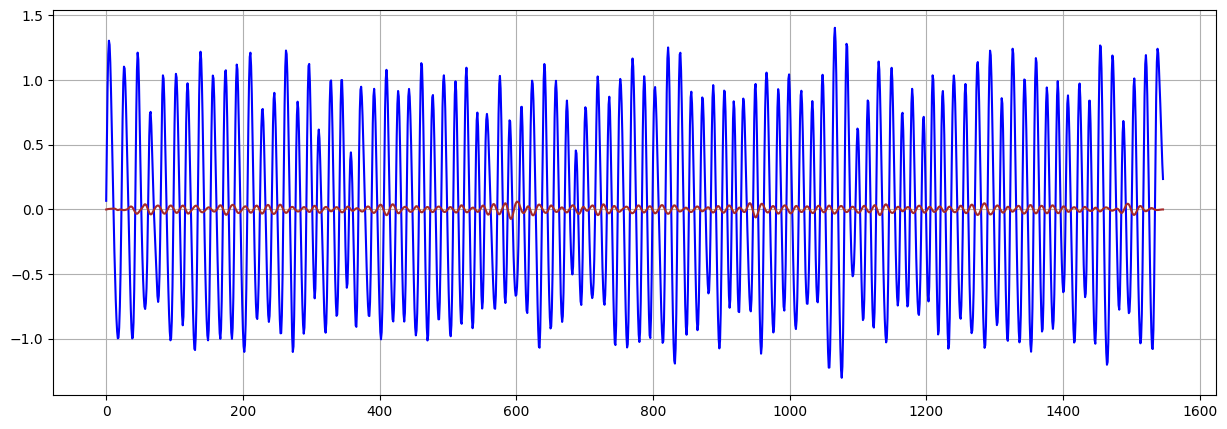

In [15]:
# сглаживание ground-truth и предсказанного bvp
labels = detrend(gt_bvp, 100)
predictions = detrend(bvp, 100)

# фильтрация Баттерворта 
b, a = signal.butter(1, [0.75 / fps * 2, 2.5 / fps * 2], btype='bandpass')
predictions = signal.filtfilt(b, a, np.double(predictions))
labels = signal.filtfilt(b, a, np.double(labels))

plt.figure(figsize = (15, 5))
plt.grid(True)
plt.plot(labels, c="blue")
plt.plot(predictions, c="brown")

In [82]:

def compute_macc(pred_signal, gt_signal):
    """Calculate maximum amplitude of cross correlation (MACC) by computing correlation at all time lags.
        Args:
            pred_ppg_signal(np.array): predicted PPG signal 
            label_ppg_signal(np.array): ground truth, label PPG signal
        Returns:
            MACC(float): Maximum Amplitude of Cross-Correlation
    """
    pred = deepcopy(pred_signal)
    gt = deepcopy(gt_signal)
    pred = np.squeeze(pred)
    gt = np.squeeze(gt)
    min_len = np.min((len(pred), len(gt)))
    pred = pred[:min_len]
    gt = gt[:min_len]
    lags = np.arange(0, len(pred)-1, 1)
    tlcc_list = []

    for lag in lags:
        cross_corr = np.abs(np.corrcoef(pred, np.roll(gt, lag))[0][1])
        tlcc_list.append(cross_corr)

    macc = max(tlcc_list)

    return macc

# вычисляем максимальный коэффициент корреляции сигналов со сдвигом
macc = compute_macc(predictions, labels)
print(f"MACC: {macc}")

MACC: 0.8074435160413265


In [87]:
def calculate_fft_hr(ppg_signal, fps=30, low_pass=0.75, high_pass=2.5):
    """Calculate heart rate based on PPG using Fast Fourier transform (FFT)."""
    
    ppg_signal = np.expand_dims(ppg_signal, 0)
    n = ppg_signal.shape[1]
    N = 2 ** (n - 1).bit_length() # Calculate the nearest power of 2
    f_ppg, pxx_ppg = signal.periodogram(ppg_signal, fs=fps, nfft=N, detrend=False)
    fmask_ppg = np.argwhere((f_ppg >= low_pass) & (f_ppg <= high_pass))
    mask_ppg = np.take(f_ppg, fmask_ppg)
    mask_pxx = np.take(pxx_ppg, fmask_ppg)
    fft_hr = np.take(mask_ppg, np.argmax(mask_pxx, 0))[0] * 60

    return fft_hr

# вычисляем частоту сердцебиения с помощью преобразования Фурье
hr_label = calculate_fft_hr(labels, fps)
hr_pred = calculate_fft_hr(predictions, fps)

MAE_FFT = np.abs(hr_label - hr_pred) # при обработки нескольких видео нужно усреднить

print(f"частота сердцебиения gt: {hr_label}, prediction: {hr_pred}")
print(f"FFT MAE (FFT Label): {MAE_FFT}")

частота сердцебиения gt: 109.86328125, prediction: 109.86328125
FFT MAE (FFT Label): 0.0


In [85]:
def calculate_SNR(pred_ppg_signal, hr_label, fps=30, low_pass=0.75, high_pass=2.5):
    """Calculate SNR as the ratio of the area under the curve of the frequency spectrum around the first and second harmonics 
        of the ground truth HR frequency to the area under the curve of the remainder of the frequency spectrum, from 0.75 Hz
        to 2.5 Hz. 

        Args:
            pred_ppg_signal(np.array): predicted PPG signal 
            label_ppg_signal(np.array): ground truth, label PPG signal
            fs(int or float): sampling rate of the video
        Returns:
            SNR(float): Signal-to-Noise Ratio
    """
    # Get the first and second harmonics of the ground truth HR in Hz
    first_harmonic_freq = hr_label / 60
    second_harmonic_freq = 2 * first_harmonic_freq
    deviation = 6 / 60  # 6 beats/min converted to Hz (1 Hz = 60 beats/min)

    # Calculate FFT
    pred_ppg_signal = np.expand_dims(pred_ppg_signal, 0)
    n = pred_ppg_signal.shape[1]
    N = 2 ** (n - 1).bit_length() # Calculate the nearest power of 2
    f_ppg, pxx_ppg = signal.periodogram(pred_ppg_signal, fs=fps, nfft=N, detrend=False)

    # Calculate the indices corresponding to the frequency ranges
    idx_harmonic1 = np.argwhere((f_ppg >= (first_harmonic_freq - deviation)) & (f_ppg <= (first_harmonic_freq + deviation)))
    idx_harmonic2 = np.argwhere((f_ppg >= (second_harmonic_freq - deviation)) & (f_ppg <= (second_harmonic_freq + deviation)))
    idx_remainder = np.argwhere((f_ppg >= low_pass) & (f_ppg <= high_pass) \
     & ~((f_ppg >= (first_harmonic_freq - deviation)) & (f_ppg <= (first_harmonic_freq + deviation))) \
     & ~((f_ppg >= (second_harmonic_freq - deviation)) & (f_ppg <= (second_harmonic_freq + deviation))))

    # Select the corresponding values from the periodogram
    pxx_ppg = np.squeeze(pxx_ppg)
    pxx_harmonic1 = pxx_ppg[idx_harmonic1]
    pxx_harmonic2 = pxx_ppg[idx_harmonic2]
    pxx_remainder = pxx_ppg[idx_remainder]

    # Calculate the signal power
    signal_power_hm1 = np.sum(pxx_harmonic1**2)
    signal_power_hm2 = np.sum(pxx_harmonic2**2)
    signal_power_rem = np.sum(pxx_remainder**2)

    # Calculate the SNR as the ratio of the areas
    if signal_power_rem > 0:
        SNR = 10 * np.log10((signal_power_hm1 + signal_power_hm2) / signal_power_rem)    
    else:
        SNR = 0
    
    return SNR

# вычислим SNR метрику (отношение средней мощности сигнала к средней мощности шума в полосе сигнала)
SNR = calculate_SNR(predictions, hr_label, fps)
print(f"SNR: {SNR}")

SNR: 7.725331821805726
